Teaching Pendulum Dynamics to a NN

given a dataset from sampling a system (a simple pendulum of length L and mass M), we want to train the neural network to approximate the system dynamics

formulation 1: direct mapping
the pendulum dynamics can be described as x_{k+1} = g(x_k). by sampling the dynamics and training the neural network on that dataset, we can approximate g(x_k) with h(x_k|w).

formulation 2: residual learning
the pendulum dynamics can also be described as x_{k+1} = x_k + f(x_k)dt, then f(x_k)dt = x_{k+1} - x_k (residual). we can approximate this with h(x_k|w).
this approach is typically more efficient due to the inherent lower output magnitude, which is closer to the local minimum and therefore converges faster (aka flatter function).

in both approaches the first thing we need to do is generate a dataset from the system we want to approximate.

In [30]:
import torch
import torch.optim as optim
import torch.nn as nn
import numpy as np

Simulate System

In [ ]:
class PendulumSim:
    def __init__(self, m, l, dt):
        self.mass = m
        self.length = l
        self.g = 9.81
        self.dt = dt
        self.curr_step = 0

        self.pos = 0
        self.vel = 0

        self.reset()

    def reset(self):
        self.curr_step = 0
        self.pos = np.random.uniform(-np.pi, np.pi)
        self.vel = np.random.uniform(-1, 1)

    def step(self):
        x = np.hstack([self.pos, self.vel])
        dt = self.dt
        x_next = self.rk4(x, dt)
        self.curr_step += 1

        self.pos = (x_next[0] + np.pi) % (2 * np.pi) - np.pi  # wrap to [-pi, pi]
        self.vel = x_next[1]

        return x_next

    def f(self, x):
        p = x[0]
        v = x[1]

        p_dot = v
        v_dot = -self.g / self.length * np.sin(p)

        return np.hstack([p_dot, v_dot])
    
    def rk4(self, x, dt):
        k1 = self.f(x)
        k2 = self.f(x + 0.5*dt*k1)
        k3 = self.f(x + 0.5*dt*k2)
        k4 = self.f(x + dt*k3)
        return x + (dt/6.0)*(k1 + 2*k2 + 2*k3 + k4)

    @property
    def state(self):
        return np.hstack([self.pos, self.vel])
    

def collect_data(pendulum, num_samples=1000, reset_freq=200):
    data = []   # cols: [init pos, init vel, next_pos, next_vel], each row is a sample

    for i in range(num_samples):
        if i % reset_freq == 0:
            pendulum.reset()

        curr_state = pendulum.state
        next_state = pendulum.step()
        sample = np.hstack([curr_state, next_state])
        data.append(sample)

    return np.array(data)

# --------- Setup simulation parameters and sample ---------
m = 2.0     # kg
l = 1.0     # m
dt = 0.01  # s

pendulum1 = PendulumSim(m, l, dt)

num_samples = 10000
dataset = collect_data(pendulum1, num_samples=num_samples)  # returns a (num_samples, 4) matrix

Construct Dataset

In [32]:
# Shuffles the indices
idx = np.arange(num_samples)
np.random.shuffle(idx)

# Uses first 80 random indices for train
split = int(0.8 * num_samples)
train_idx = idx[:split]
# Uses the remaining indices for validation
val_idx = idx[split:]

# Generates train and validation sets
x_train, y_train = dataset[train_idx, :2], dataset[train_idx, 2:]
x_val, y_val = dataset[val_idx, :2], dataset[val_idx, 2:]

x_train_tensor = torch.from_numpy(x_train).float()
y_train_tensor = torch.from_numpy(y_train).float()
x_val_tensor = torch.from_numpy(x_val).float()
y_val_tensor = torch.from_numpy(y_val).float()

from torch.utils.data import DataLoader, TensorDataset
train_data = TensorDataset(x_train_tensor, y_train_tensor)
# train_loader = DataLoader(dataset=train_data, batch_size=16, shuffle=True)
val_data = TensorDataset(x_val_tensor, y_val_tensor)
# val_loader = DataLoader(dataset=val_data, batch_size=16, shuffle=False)

Construct Model

In [ ]:
"""
Dynamics model class. Ripped from ROB 599 Legged Robot Control lecture
"""

class DirectDynamicsModel(nn.Module):
    def __init__(self, state_dim, action_dim, hidden_dim=64):
        """
        Initializes the DynamicsModel with given dimensions.

        Args:
            state_dim (int): Dimension of the state space.
            action_dim (int): Dimension of the action space.
            hidden_dim (int): Dimension of the hidden layers.
        """
        super(DirectDynamicsModel, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(state_dim + action_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, state_dim)
        )

    def forward(self, state, action=None):
        """
        Forward pass through the model.

        Args:
            state (torch.Tensor): Current state tensor.
            action (torch.Tensor): Action tensor.

        Returns:
            torch.Tensor: Predicted next state tensor.
        """
        if action is not None:
            x = torch.cat([state, action], dim=-1)
        else:
            x = state
        next_state = self.model(x)
        return next_state
    

class ResidualDynamicsModel(nn.Module):
    def __init__(self, state_dim, action_dim, hidden_dim=64):
        """
        Initializes the ResidualDynamicsModel with given dimensions.

        Args:
            state_dim (int): Dimension of the state space.
            action_dim (int): Dimension of the action space.
            hidden_dim (int): Dimension of the hidden layers.
        """
        super(ResidualDynamicsModel, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(state_dim + action_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, state_dim)
        )

    def forward(self, state, action=None):
        """
        Forward pass through the model.

        Args:
            state (torch.Tensor): Current state tensor.
            action (torch.Tensor): Action tensor.

        Returns:
            torch.Tensor: Predicted next state tensor.
        """
        if action is not None:
            x = torch.cat([state, action], dim=-1)
        else:
            x = state
        delta_state = self.model(x)
        next_state = state + delta_state
        return next_state

Train Model

In [ ]:
from torch.utils.data import DataLoader
device = 'cuda' if torch.cuda.is_available() else 'cpu'

def train_model(model, dataset, num_epochs=100, batch_size=64, learning_rate=1e-3):
    """
    Trains the given dynamics model using the provided dataset.

    Args:
        model (torch.nn.Module): The dynamics model to train.
        dataset (DynamicsDataset): The dataset containing training samples.
        num_epochs (int): Number of training epochs.
        batch_size (int): Size of each training batch.
        learning_rate (float): Learning rate for the optimizer.
    """
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    loss_fn = torch.nn.MSELoss()
    loss_log = []

    for epoch in range(num_epochs):
        total_loss = 0.0
        for states, next_states in dataloader:
            optimizer.zero_grad()
            states = states.to(device)
            predicted_next_states = model(states)
            loss = loss_fn(predicted_next_states, next_states)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        avg_loss = total_loss / len(dataloader)
        loss_log.append(avg_loss)
        print(f"Epoch {epoch + 1}/{num_epochs}, Loss: {avg_loss:.6f}")
    
    return loss_log

def eval_model(model, dataset):
    """
    Evaluates the given dynamics model using the provided dataset.

    Args:
        model (torch.nn.Module): The dynamics model to evaluate.
        dataset (DynamicsDataset): The dataset containing evaluation samples.

    Returns:
        float: The average loss over the evaluation dataset.
    """
    dataloader = DataLoader(dataset, batch_size=64, shuffle=False)
    loss_fn = torch.nn.MSELoss()
    total_loss = 0.0

    model.eval()
    with torch.no_grad():
        for states, next_states in dataloader:
            predicted_next_states = model(states)
            loss = loss_fn(predicted_next_states, next_states)
            total_loss += loss.item()

    avg_loss = total_loss / len(dataloader)
    return avg_loss


torch.manual_seed(42)

# Direct Dynamics Model
direct_model = DirectDynamicsModel(2, 0).to(device)
# Train model
direct_loss_log = train_model(direct_model, train_data, num_epochs=50, batch_size=32, learning_rate=1e-3)
        
# Evaluate model
val_loss = eval_model(direct_model, val_data)
print(f"Validation Loss: {val_loss:.6f}")

# Save trained model and loss log
torch.save(direct_model.state_dict(), "direct_dynamics_model.pt")
print("Trained model saved to direct_dynamics_model.pt")
np.save("direct_loss_log.npy", direct_loss_log)

# Do the same for the residual model
residual_model = ResidualDynamicsModel(2, 0).to(device)
residual_loss_log = train_model(residual_model, train_data, num_epochs=50, batch_size=32, learning_rate=1e-3)
val_loss = eval_model(residual_model, val_data)
print(f"Validation Loss: {val_loss:.6f}")
torch.save(residual_model.state_dict(), "residual_dynamics_model.pt")
print("Trained model saved to residual_dynamics_model.pt")
np.save("residual_loss_log.npy", residual_loss_log)


Epoch 1/50, Loss: 0.339555
Epoch 2/50, Loss: 0.000703
Epoch 3/50, Loss: 0.000302
Epoch 4/50, Loss: 0.000198
Epoch 5/50, Loss: 0.000162
Epoch 6/50, Loss: 0.000122
Epoch 7/50, Loss: 0.000094
Epoch 8/50, Loss: 0.000082
Epoch 9/50, Loss: 0.000077
Epoch 10/50, Loss: 0.000074
Epoch 11/50, Loss: 0.000059
Epoch 12/50, Loss: 0.000088
Epoch 13/50, Loss: 0.000056
Epoch 14/50, Loss: 0.000107
Epoch 15/50, Loss: 0.000060
Epoch 16/50, Loss: 0.000086
Epoch 17/50, Loss: 0.000071
Epoch 18/50, Loss: 0.000058
Epoch 19/50, Loss: 0.000243
Epoch 20/50, Loss: 0.000053
Epoch 21/50, Loss: 0.000192
Epoch 22/50, Loss: 0.000045
Epoch 23/50, Loss: 0.000048
Epoch 24/50, Loss: 0.000108
Epoch 25/50, Loss: 0.000144
Epoch 26/50, Loss: 0.000052
Epoch 27/50, Loss: 0.000063
Epoch 28/50, Loss: 0.000196
Epoch 29/50, Loss: 0.000192
Epoch 30/50, Loss: 0.000074
Epoch 31/50, Loss: 0.000048
Epoch 32/50, Loss: 0.000087
Epoch 33/50, Loss: 0.000100
Epoch 34/50, Loss: 0.000140
Epoch 35/50, Loss: 0.000041
Epoch 36/50, Loss: 0.000175
E

Visualization

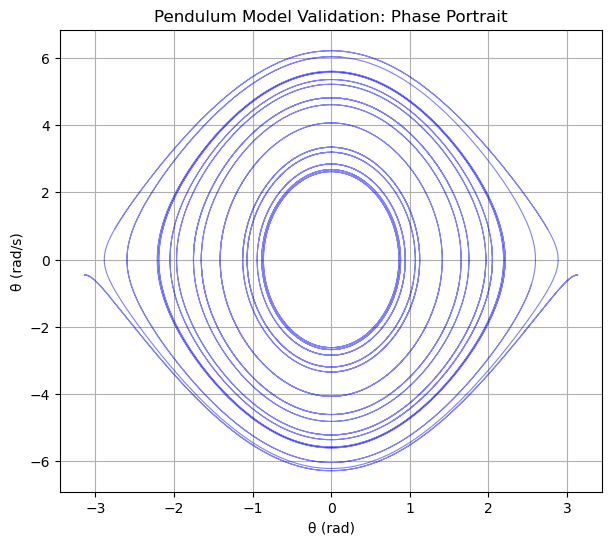

In [45]:
import matplotlib.pyplot as plt

# After collecting states into a numpy array
def mask_wraps(states, threshold=np.pi):
    masked = states.copy()
    jumps = np.abs(np.diff(states[:, 0])) > threshold
    masked[1:][jumps] = np.nan  # break the line at wrap points
    return masked

def plot_phase_portrait(pendulum, n_trajectories=15, T=6.0):
    fig, ax = plt.subplots(figsize=(7, 6))
    
    for _ in range(n_trajectories):
        pendulum.reset()
        states = [pendulum.state]
        steps = int(T / pendulum.dt)
        for _ in range(steps):
            pendulum.step()
            states.append(pendulum.state)
        states = np.array(states)
        masked = mask_wraps(states)
        ax.plot(masked[:, 0], masked[:, 1], 'b', alpha=0.5, linewidth=0.8)
    
    ax.set_xlabel('θ (rad)')
    ax.set_ylabel('θ̇ (rad/s)')
    ax.set_title('Pendulum Model Validation: Phase Portrait')
    ax.grid(True)
    plt.show()

plot_phase_portrait(pendulum1)

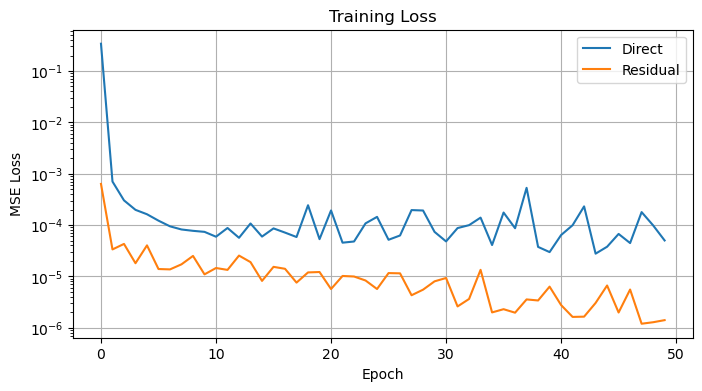

In [36]:
plt.figure(figsize=(8, 4))
plt.plot(direct_loss_log, label='Direct')
plt.plot(residual_loss_log, label='Residual')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.yscale('log')  # log scale makes it easier to see convergence behavior
plt.title('Training Loss')
plt.legend()
plt.grid(True)
plt.show()

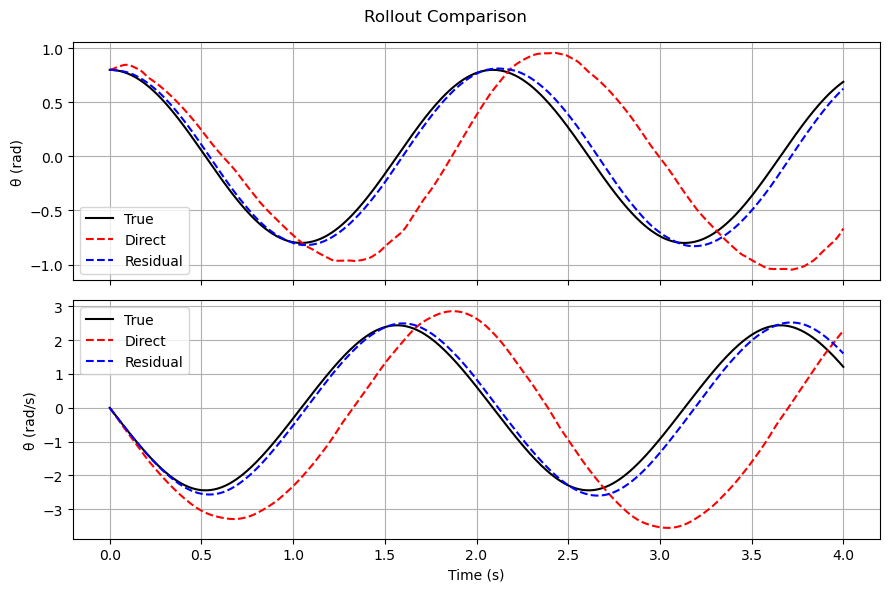

In [ ]:
def rollout(model, initial_state, steps):
    """Roll out a trajectory by feeding predictions back as inputs."""
    model.eval()
    states = [initial_state]
    state = torch.tensor(initial_state, dtype=torch.float32).unsqueeze(0)  # (1, 2)

    # print("initial state:", initial_state)
    # print("first prediction:", model(torch.tensor(initial_state, dtype=torch.float32).unsqueeze(0)))
    
    with torch.no_grad():
        for i in range(steps):
            next_state = model(state)
            val = next_state.squeeze(0).detach().cpu().numpy()
            val[0] = (val[0] + np.pi) % (2 * np.pi) - np.pi  # wrap angle
            states.append(val)
            state = next_state

    states = np.array(states)
    
    return np.array(mask_wraps(states))

def plot_rollout_comparison(pendulum, direct_model, residual_model, T=4.0):
    steps = int(T / pendulum.dt)
    
    # Simulate ground truth from a fixed initial condition
    pendulum.pos = 0.8  # fix initial condition so it's repeatable
    pendulum.vel = 0.0
    true_states = [pendulum.state]
    for _ in range(steps):
        pendulum.step()
        true_states.append(pendulum.state)
    true_states = np.array(true_states)
    
    initial_state = true_states[0]
    direct_states = rollout(direct_model, initial_state, steps)
    residual_states = rollout(residual_model, initial_state, steps)
    
    t = np.linspace(0, T, steps + 1)
    fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
    
    for ax, dim, label in zip(axes, [0, 1], ['θ (rad)', 'θ̇ (rad/s)']):
        ax.plot(t, true_states[:, dim], 'k', label='True', linewidth=1.5)
        ax.plot(t, direct_states[:, dim], 'r--', label='Direct')
        ax.plot(t, residual_states[:, dim], 'b--', label='Residual')
        ax.set_ylabel(label)
        ax.legend()
        ax.grid(True)
    
    axes[1].set_xlabel('Time (s)')
    fig.suptitle('Rollout Comparison')
    plt.tight_layout()
    plt.show()

plot_rollout_comparison(pendulum1, direct_model, residual_model)

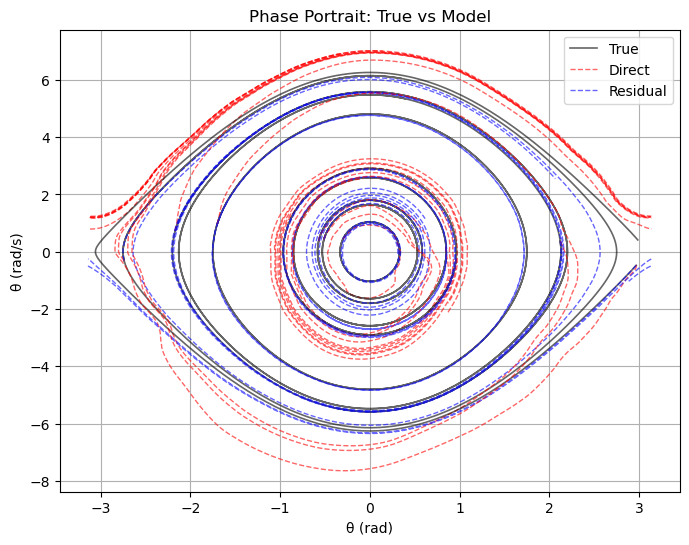

In [44]:
def plot_phase_portrait_overlay(pendulum, direct_model, residual_model, n_trajectories=10, T=5.0):
    fig, ax = plt.subplots(figsize=(8, 6))
    steps = int(T / pendulum.dt)
    
    for i in range(n_trajectories):
        pendulum.reset()
        initial_state = pendulum.state
        
        # True trajectory
        true_states = [initial_state]
        for _ in range(steps):
            pendulum.step()
            true_states.append(pendulum.state)
        true_states = np.array(true_states)
        
        # Model rollouts
        direct_states = rollout(direct_model, initial_state, steps)
        residual_states = rollout(residual_model, initial_state, steps)
        
        # Only label once
        label_true = 'True' if i == 0 else None
        label_direct = 'Direct' if i == 0 else None
        label_residual = 'Residual' if i == 0 else None
        
        ax.plot(true_states[:, 0], true_states[:, 1], 'k', alpha=0.6, linewidth=1.2, label=label_true)
        ax.plot(direct_states[:, 0], direct_states[:, 1], 'r--', alpha=0.6, linewidth=1.0, label=label_direct)
        ax.plot(residual_states[:, 0], residual_states[:, 1], 'b--', alpha=0.6, linewidth=1.0, label=label_residual)
    
    ax.set_xlabel('θ (rad)')
    ax.set_ylabel('θ̇ (rad/s)')
    ax.set_title('Phase Portrait: True vs Model')
    ax.legend()
    ax.grid(True)
    plt.show()

plot_phase_portrait_overlay(pendulum1, direct_model, residual_model)

both the direct and the residual models are able to converge sucessfully. the residual model out performs the direct model as expected. from the phase portraits you can see that the residual model matches the true sim pretty closely, while the direct model struggles more. from the rollout graph you can see both models' accuracy degrades over longer time, with the direct model being more extreme. i think this is because the models were both trained on short trajectories (x_i, x_{i+1}) so they would probably accumulate error as they try to propogate further than the training data. overall fun demo!